In [1]:
import numpy as np
import scipy.stats as st
import sklearn.linear_model as lm
import matplotlib.pyplot as plt
import pandas as pd
from io import StringIO
%matplotlib inline
import time

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import statsmodels
import seaborn as sns
import bioinfokit #for volcano plotting
import pickle

In [2]:
from sklearn.model_selection import LeaveOneGroupOut,LeaveOneOut
logo = LeaveOneGroupOut()

In [3]:
import os
# change this to your overall folder that contains the data
os.chdir('D:/BOX/Box Sync/RA/data/SPEC/REIMS cell comparison/')
os.getcwd()

'D:\\BOX\\Box Sync\\RA\\data\\SPEC\\REIMS cell comparison'

In [4]:
# list all csv file in folder
from os import listdir
 
def list_files(directory, extension):
    return (f for f in listdir(directory) if f.endswith('.' + extension))

directory = "ICL_NPL_COMBINED/"

files = list_files(directory, "csv")
filenames=[]
for f in files:
    filenames.append(f)

print(len(filenames))    
filenames

4


['Bipolar forceps Medimass combined_matrix.csv',
 'Bipolar forceps Waters combined_matrix.csv',
 'Cell probe Medimass combined_matrix.csv',
 'Cell probe Waters combined_matrix.csv']

In [339]:
# change this directory to your specific folder

# file = pd.read_csv("OPO_plate_reader_Medimass_REIMS_30102020/LD_REIMS_medimass_2.csv")
# file = pd.read_csv("Bipolar forceps_Medimass_REIMS_07072020/bipolar_medimass.csv")
# file = pd.read_csv("Bipolar forceps_Waters_REIMS_14072020/bipolar_waters.csv")
# file = pd.read_csv("Cell probe_Medimass_REIMS_24022021/cellprobe_medimass.csv")
# file = pd.read_csv("Cell probe_Waters_REIMS_25032021/cellprobe_waters.csv")
# file = pd.read_csv("Bipolar forceps_Exactive_REIMS/bipolar_Exactive.csv")
# file = pd.read_csv("Cell_probe_Exactive_REIMS/cellprobe_Exactive.csv")


# NPL data
# file = pd.read_csv("NPL Bipolar forceps Medimass REIMS/NPL_bipolar_medimass.csv")
# file = pd.read_csv("NPL Bipolar forceps Waters REIMS/NPL_bipolar_waters.csv")
# file = pd.read_csv("NPL Cell probe Medimass REIMS/NPL_cellprobe_medimass.csv")
# file = pd.read_csv("NPL Cell probe Waters REIMS/NPL_cellprobe_waters.csv")
# file = pd.read_csv("NPL Bipolar forceps Medimass REIMS/NPL_bipolar_medimass_select_balanced3.csv")
# file = pd.read_csv("NPL Bipolar forceps Waters REIMS/NPL_bipolar_waters_select_balanced.csv")
# file = pd.read_csv("NPL Cell probe Medimass REIMS/NPL_cellprobe_medimass_select_balanced.csv")



# Data with selected fetures
# file = pd.read_csv("feature selection/bipolar_forceps_medimass_RFE.csv")
# tmp_train = file

# Data= file.iloc[:,2:] # everything that's not from feature selection folder
# Data= file.iloc[:,:-2] # for feature selection folder files, should just synchronise the format...
# Data=Data.fillna(0)

# combined data
filename = filenames[3]
print(filename)

file = pd.read_csv(directory+filename)

select1 = []
select2 = []
for i in range(len(file)):
    select1.append('ICL' in file['Class'][i])
    select2.append('NPL' in file['Class'][i])

tmp_train = file.iloc[select1,:]
tmp_test = file.iloc[select2,:]    

Data_train = tmp_train.iloc[:,2:]
Data_train =Data_train.fillna(0)
Data_test = tmp_test.iloc[:,2:]
Data_test =Data_test.fillna(0)

file



Cell probe Waters combined_matrix.csv


,Sample,Class,90.0076,92.0242,92.9252,94.9227,96.9573,107.0341,117.0178,119.0336,...,1209.9912,1210.995,1211.9964,1219.9849,1224.0031,1234.0011,1234.9931,1247.998,1249.002,1282.0501
0,ICL_BT549_TR1,ICL_BT549,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.00000,0.000000,0.000000,0.000000,0.0
1,ICL_BT549_TR2,ICL_BT549,0.0,0.0,2449.142330,2532.362138,3483.113577,3797.972902,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.00000,0.000000,399.491603,0.000000,0.0
2,ICL_BT549_TR3,ICL_BT549,0.0,0.0,10729.539420,11091.987790,0.000000,35035.055100,48639.142560,8745.02321,...,798.013756,602.269683,0.000000,667.280964,0.0,619.95243,664.671852,0.000000,0.000000,0.0
3,ICL_BT549_TR4,ICL_BT549,0.0,0.0,0.000000,0.000000,0.000000,3899.924258,6511.059186,0.00000,...,0.000000,0.000000,356.922882,0.000000,0.0,0.00000,0.000000,0.000000,0.000000,0.0
4,ICL_BT549_TR5,ICL_BT549,0.0,0.0,0.000000,0.000000,0.000000,0.000000,1000.660587,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.00000,0.000000,0.000000,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
631,NPL_T47D_TR26,NPL_T47D,0.0,0.0,1185.342268,695.530637,26714.850210,420.154403,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.00000,0.000000,93.149516,162.351312,0.0
632,NPL_T47D_TR27,NPL_T47D,0.0,0.0,3362.843166,1566.722083,31646.735570,1195.496461,1208.261459,0.00000,...,197.602992,257.882177,0.000000,200.566602,0.0,0.00000,0.000000,0.000000,0.000000,0.0
633,NPL_T47D_TR28,NPL_T47D,0.0,0.0,1225.656222,543.999532,47294.129830,470.346307,431.859301,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.00000,0.000000,0.000000,0.000000,0.0
634,NPL_T47D_TR29,NPL_T47D,0.0,0.0,1660.941790,797.786663,33974.189410,1069.119618,781.522541,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.00000,0.000000,0.000000,0.000000,0.0


# Randomly re-sample positive/negative to balance

In [64]:
# from sklearn.utils.random import sample_without_replacement as resample

# positives = (file['Label'] == 'Positive')
# positives = file[positives]
# negatives = (file['Label'] == 'Negative')
# negatives = file[negatives]

# # sample_50pos = resample (n_population=(len(positives)),n_samples=50)
# # sample_50pos = positives
# sample_50neg = resample (n_population=(len(negatives)),n_samples=68)

# data_pos = positives
# data_neg = negatives.iloc[sample_50neg,:]

# frames=[data_pos, data_neg]
# file_resample= pd.concat(frames)
# Data_resample = file_resample.iloc[:,2:209]
# # Data_resample = pd.concat(frames)
# label = file_resample['Label'].tolist()

# Data = Data_resample
# Data

In [65]:
# mean_pos = np.mean(data_pos.iloc[:,100:59761])
# mean_neg = np.mean(data_neg.iloc[:,100:59761])
# plt.plot(mz_trans, mean_pos, mz_trans, mean_neg)

In [134]:
#sub-grouping

# # subgroup=file.replace("APC_control","APC")
# subgroup=file.replace("APC_KRAS_control","KRAS")
# # entire_slide=entire_slide.replace("APC_P53_control","control")
# subgroup=subgroup.replace("APC_KRAS_P53_control","KRAS+P53")
# # subgroup=subgroup.replace("APC_sim","APC")
# subgroup=subgroup.replace("APC_KRAS_sim","KRAS")
# # entire_slide=entire_slide.replace("APC_P53_sim","sim")
# subgroup=subgroup.replace("APC_KRAS_P53_sim","KRAS+P53")
# label_sub=(subgroup['Label']== "KRAS+P53") | (subgroup['Label']== "KRAS")
# tmp1=subgroup[label_sub]
# Data = tmp1.iloc[:,2:]
# Data

# Get m/z and normalisations

In [342]:
data = Data_test
tmp_mz = data.columns.values #define m/z axis
mz = tmp_mz.astype(np.float)
mz_trans=mz.transpose()
# mz_trans
mz_trans=np.reshape(mz_trans,(-1,1))
mz_trans.shape

(463, 1)

In [9]:
# save if needed
# np.savetxt('Bipolar forceps_Medimass_REIMS_07072020/mz.txt', mz_trans,delimiter=',')

In [31]:
# Normalisation * do not need most cases, actually worsens performance!

Data_n=np.zeros((len(Data),len(features_LR2)))
for i in range (0,len(Data)):
    Data_n[i] = Data_r[i]/np.median(Data_r[i])
Data_n.shape

In [ ]:
# snv transform/normalisation to centre mean

from sklearn.preprocessing import StandardScaler
Data_snv=StandardScaler().fit_transform(Data)
# Data_snv.shape

In [343]:
# log transform

tmp_log = data[data != 0]
logOS = np.nanmedian(tmp_log)
Data_log = np.log(data+logOS)
Data_log.shape

(292, 463)

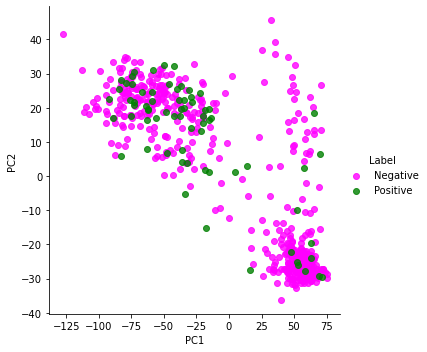

In [25]:
# sparse PCA *i.e. if your number of features >> number of samples/patients

from sklearn.decomposition import SparsePCA
# spca=SparsePCA(n_components=3,random_state=0)
# sX_2D = spca.fit(Data_log).transform(Data_log)
# sloadings = pd.DataFrame(spca.components_.T, columns=['PC1', 'PC2','PC3'])
# sPCA_data=file
sPCA_data['PC1'] = sX_2D[:,0]
sPCA_data['PC2'] = sX_2D[:,1]
colors=['magenta','green','navy', 'r', 'b', 'y', 'orange', 'indigo']
group_label = list(sPCA_data.columns)
sns.lmplot("PC1", "PC2", hue=group_label[1], data=sPCA_data, palette=colors, fit_reg=False)

D:\anaconda3\lib\site-packages\ipykernel_launcher.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  from ipykernel import kernelapp as app
D:\anaconda3\lib\site-packages\ipykernel_launcher.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  app.launch_new_instance()


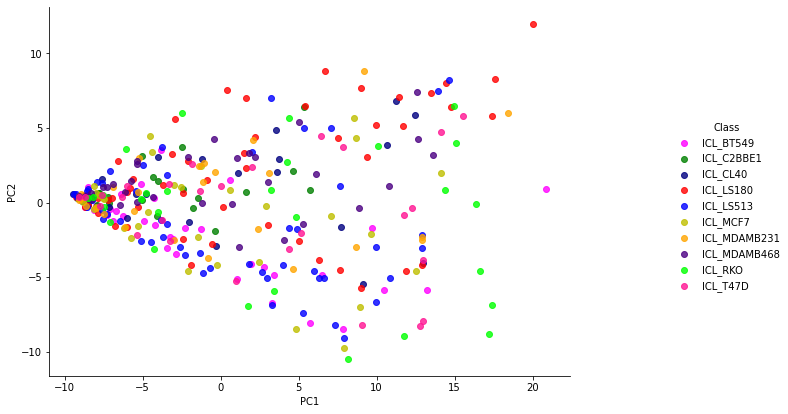

In [126]:
# PCA

from sklearn.decomposition import PCA
pca = PCA(n_components=3) #keep first 3 components
X_2D = pca.fit(Data_log).transform(Data_log)
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2','PC3'])

# label,y= np.unique(file['Label'],return_inverse = True)
# # label=file['Label']
# colors = ['green','red']
colors=['magenta','green','navy', 'r', 'b', 'y', 'orange', 'indigo','lime', 'deeppink', 'deepskyblue']
# lw = 1

PCA_data=tmp_train
PCA_data['PC1'] = X_2D[:,0]
PCA_data['PC2'] = X_2D[:,1]


sns.lmplot("PC1", "PC2", hue='Class', data=PCA_data, palette=colors,fit_reg=False)
fig = plt.gcf()
fig.set_size_inches(12,6)

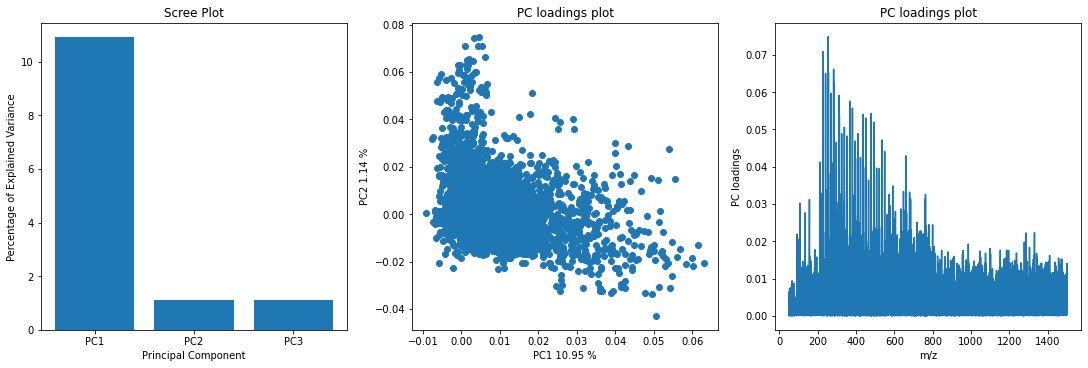

In [62]:
per_var = np.round(pca.explained_variance_ratio_* 100, decimals=1)
labels = ['PC' + str(x) for x in range(1, len(per_var)+1)]

fig,axs = plt.subplots(ncols=3,constrained_layout=True,figsize=(15,5))

axs[0].bar(x=range(1,len(per_var)+1), height=per_var, tick_label=labels)
axs[0].set_ylabel('Percentage of Explained Variance')
axs[0].set_xlabel('Principal Component')
axs[0].set_title('Scree Plot')

axs[1].scatter(loadings['PC1'],loadings['PC2'])
axs[1].set_title('PC loadings plot')
axs[1].set_xlabel('PC1 %0.2f %%' % (pca.explained_variance_ratio_[0] * 100))
axs[1].set_ylabel('PC2 %0.2f %%' % (pca.explained_variance_ratio_[1] * 100))

axs[2].plot(mz,loadings['PC2'].abs())
# axs[2].plot(mz,loadings['PC3'])
axs[2].set_title('PC loadings plot')
axs[2].set_xlabel('m/z')
axs[2].set_ylabel('PC loadings');


## Feature selection using PCA (if clear separation visible)

In [121]:
# PC=loadings['PC2']
# np.savetxt('D:/BOX//Box Sync/RA/data/IMAGING/DESI/CRUK/project B/mz.txt', mz,delimiter=',')
# # np.savetxt('D:/BOX//Box Sync/RA/data/IMAGING/DESI/CRUK/project b/pc.txt', PC,delimiter=',') #for me to save the components

# sorted_loading_values = PC.abs().sort_values(ascending=False)
# # sorted_loading_values
# top_30_mz = sorted_loading_values[0:100].index
# top_30_mz
# PCA_features=mz[top_30_mz]
# np.savetxt('D:/BOX/Box Sync/RA/data/IMAGING/DESI/CRUK/project B/features_PCA.txt', PCA_features,delimiter=',')

## Check some spectra

MDAMB231


<function matplotlib.pyplot.show(*args, **kw)>

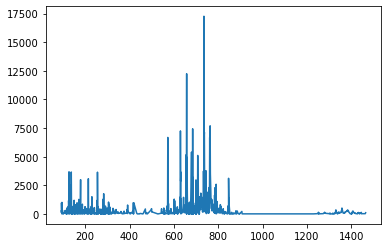

In [61]:
classname = labelnames[6]
select = Data[file['Class']== classname]
print(classname)
spec = np.mean(select.values,axis = 0)
spec.shape
plt.plot(mz,spec)
plt.show

# Classification models

In [196]:
# check group sizes

# labelnames = set(tmp_train['Class'])
labelnames = set(tmp_train['Label'])
labelnames = list(labelnames)

w = np.zeros(len(labelnames))
for i in range(0,len(labelnames)):
    group=tmp_train[tmp_train['Label']== labelnames[i]]
    w[i]=(len(group))
    print('group' + str(i) + ' sampe size: '+str(w[i])+'\n')

print('ratio: '+str(w/max(w)))
weights = {labelnames[0]:1.0, labelnames[1]:w[0]/w[1]}

# labelnames

group0 sampe size: 32.0

group1 sampe size: 56.0

group2 sampe size: 46.0

group3 sampe size: 53.0

group4 sampe size: 45.0

group5 sampe size: 56.0

group6 sampe size: 25.0

group7 sampe size: 42.0

group8 sampe size: 21.0

group9 sampe size: 51.0

group10 sampe size: 45.0

ratio: [0.57142857 1.         0.82142857 0.94642857 0.80357143 1.
 0.44642857 0.75       0.375      0.91071429 0.80357143]


In [145]:
# label = file['Class'].tolist()
label = tmp_train['Class'].tolist()
for i in range(len(label)):
    label[i] = label[i][4:]
    
models = []
models.append(('LR', LogisticRegression(solver='liblinear')))
# models.append(('LDA', LinearDiscriminantAnalysis()))
# models.append(('KNN', KNeighborsClassifier()))
# models.append(('CART', DecisionTreeClassifier()))
# models.append(('NB', GaussianNB()))
# models.append(('SVM', SVC()))
# num_trees = 150
# max_features = 10
# models.append(('RF', RandomForestClassifier(n_estimators= num_trees, max_features=max_features)))
# modelList = ['LR','LDA','KNN','CART','SVM','RF'];
modelList = ['LR'];
scoring = 'accuracy'

# Store results in a pandas dataframe
numIterations = 10;
cv_results=pd.DataFrame(index=range(0,len(Data_log)), columns=modelList)
n=1



start_time = time.time()
# perform classification using all models (10 iterations for RF) and compare results (mean,std)
for i in range(0,len(modelList)):
        # LOOCV 
        cvFold = logo.split(Data_log,label,groups=tmp_train['Sample'])
        name, model=models[i]

        # only RF needs to be iterated as everything else deterministic
        if name == 'RF':
            RF_results=np.zeros((len(Data_log),numIterations))
            for n in range(0,numIterations):
                cvFold = logo.split(Data_log,label,groups=tmp_train['Sample'])
                RF_results[:,n]=cross_val_predict(model, Data_log, label, cv=cvFold, scoring=scoring)
                msg = "Method %s iteration %d \r" % (name, n)
                print(msg,end="")
            cv_results.iloc[:,i]=(RF_results/numIterations).sum(axis=1)
        else:
            cv_results.iloc[:,i]=cross_val_predict(model, Data_log, label, cv=cvFold)
            # Status message
            msg = "Method %s iteration %d \r" % (name, n)
            print(msg,end="")

elapsed_time = time.time() - start_time
print()
print('that took '+str(elapsed_time)+' seconds')

Method LR iteration 1 
that took 171.95104336738586 seconds


## save trained model(s)

In [149]:
name,model_tosave = models[0]
print(name)
model_tosave.fit(Data_r3, label)
# filename = ''
pickle.dump(model_tosave, open('trained models/LR_cellprobe_waters_combined_balanced.sav', 'wb'))

LR


## load trained model(s) & validate on test data

In [344]:
# load selected features from file
file_select = pd.read_csv("feature selection/cellprobe_waters_combined_RFE_balanced.csv")
data_select = file_select.iloc[:,:-2]
features_LR = np.asarray(data_select.columns.astype(float))
features_LR.shape

(130,)

In [345]:
Data_test=np.zeros((len(Data_log),len(features_LR)))
for n in range (0,len(features_LR)):
    index = np.argmin(abs(mz-features_LR[n]))
    Data_test[:,n]=Data_log.iloc[:,index]
# for n in range (0,len(features_ttest)):
#     Data_r[:,n]=file.iloc[:,(features_ttest[n])]
Data_test.shape

(292, 130)

In [346]:
filename = 'trained models/LR_cellprobe_waters_combined_balanced.sav'
loaded_model = pickle.load(open(filename, 'rb'))
test_results = loaded_model.predict(Data_test)

In [66]:
# test_results
# test_results = [w.replace('HEK', 'HEK293T') for w in test_results]
# test_results.replace('HEK','HEK293T')

# Performance analysis with confusion matrix & ROC curve

In [11]:
# function to calculate confusion matrix
def calculate_cm (cv_results, label):
    results=pd.DataFrame(index=range(0,len(label)), columns=['LOOCV results','labels'])
    results.iloc[:,0]=cv_results
    results.iloc[:,1]=label
    labelnames = set(label)
    labelnames = list(labelnames)
    dims = len(labelnames)
    
    #calculate diagonals for TPs & TNs
    TRUE = []
#     TN = []
    for i in range (0,dims):
        condition1=(results['LOOCV results']==1) & (results['labels'] == labelnames[i])
        dum=results[condition1]
        TRUE.append(len(dum))
    
    FALSE = []
    #calculate other elements
    for i in range (0,dims):
        condition2=(results['LOOCV results']==0) & (results['labels'] == labelnames[i])
        dum=results[condition2]
        FALSE.append(len(dum))
    c_matrix=np.zeros((dims,dims))
    for i in range (0, dims):
        for j in range (0, dims):
            if i == j:
                c_matrix[i,j]= TRUE [i]
            else:
                c_matrix[i,j]= FALSE [i]
    return c_matrix

In [132]:
from matplotlib.lines import Line2D

compare_data = pd.DataFrame(index=range(0,len(modelList)),columns=['model','accuracy',
                                                               'sensitivity',
                                                               'specificity'])
compare_data.iloc[:]['model']=modelList


for i in range (0,(len(modelList)-1)):
    c_matrix = calculate_cm(cv_results.iloc[:,i],label)
    if len(c_matrix) > 2:
        switch = 'multi'
        acc = cv_results.iloc[:,i].mean()
        sen = 'n/a'
        spec = 'n/a'
    else:
        switch = 'binary'
        acc = (c_matrix[0,0]+c_matrix[1,1])/(c_matrix[0,0]+c_matrix[1,1]+c_matrix[0,1]+c_matrix[1,0])*100
        sen = (c_matrix[0,0])/(c_matrix[0,0]+c_matrix[0,1])*100
        spec = (c_matrix[1,1])/(c_matrix[1,1]+c_matrix[1,0])*100
    compare_data.iloc[i]['accuracy'] = acc
    compare_data.iloc[i]['sensitivity'] = sen
    compare_data.iloc[i]['specificity'] = spec
    

if switch == 'multi':
    acc = RF_results.mean()
    sen = 'n/a'
    spec = 'n/a'
    compare_data.iloc[5]['accuracy'] = acc
    compare_data.iloc[5]['sensitivity'] = sen
    compare_data.iloc[5]['specificity'] = spec
else:
    RF_acc = np.zeros(numIterations)
    RF_sen = np.zeros(numIterations)
    RF_spec = np.zeros(numIterations)
    for i in range (0, numIterations):
        c_matrix = calculate_cm(RF_results[:,i],label)
        acc = (c_matrix[0,0]+c_matrix[1,1])/(c_matrix[0,0]+c_matrix[1,1]+c_matrix[0,1]+c_matrix[1,0])*100
        sen = (c_matrix[0,0])/(c_matrix[0,0]+c_matrix[0,1])*100
        spec = (c_matrix[1,1])/(c_matrix[1,1]+c_matrix[1,0])*100
        RF_acc[i] = acc
        RF_sen[i] = sen
        RF_spec[i] = spec
    compare_data.iloc[5]['accuracy'] = RF_acc.mean()
    compare_data.iloc[5]['sensitivity'] = RF_sen.mean()
    compare_data.iloc[5]['specificity'] = RF_spec.mean()
    
print(compare_data)
fig, ax = plt.subplots()
if switch == 'multi':
    comparison_plot= ax.scatter(compare_data['model'],compare_data['accuracy'],c=['r','g','b','c','m','navy'])
else:
    comparison_plot= ax.scatter(compare_data['model'],compare_data['accuracy'],c=['r','g','b','c','m','navy'])
    ax.scatter(compare_data['model'],compare_data['sensitivity'],c=['r','g','b','c','m','navy'],marker="x")
    ax.scatter(compare_data['model'],compare_data['specificity'],c=['r','g','b','c','m','navy'],marker="d")


legend_elements = [Line2D([0], [0], marker='o', color='w', label='Acc.',
                          markerfacecolor='black', markersize=10),
                   Line2D([0], [0], marker='X', color='w', label='Sen.',
                          markerfacecolor='black', markersize=10),
                   Line2D([0], [0], marker='d', color='w', label='Spec.',
                          markerfacecolor='black', markersize=10)]
ax.legend(handles=legend_elements,loc='best')

## for multi-group study start here

In [44]:
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score

target=tmp_train.iloc[:,1]
Data_r1 = Data_log.values
kf = LeaveOneOut()
all_y = []
all_probs=[]
# name, model=models[5]
# model = SVC(probability=True)
model = LogisticRegression(solver='liblinear',class_weight=weights)

for train, test in kf.split(Data_r1, target):
    all_y.append(target[test])
    all_probs.append(model.fit(Data_r1[train], target[train]).predict_proba(Data_r1[test]))

In [45]:
cm_label = np.unique(file.iloc[:,1])

all_y = np.array(all_y)
all_probs = np.array(all_probs)
# all_probs_np = []
# for i in range(len(Data_r1)):
#     all_probs_np.append(np.array(all_probs[i]))
n_classes = len(labelnames)

print('Total classes = ' +str(n_classes))


TPRs = dict()
FPRs = dict()
AUCs = dict()
for i in range(n_classes):
    FPRs[i], TPRs[i], _ = roc_curve(all_y,all_probs[:,0,i],pos_label=cm_label[i])
#     FPRs[i], TPRs[i], _ = roc_curve(all_y,all_probs[:,i],pos_label=cm_label[i])

    AUCs[i] = auc(FPRs[i], TPRs[i])
    
# First aggregate all false positive rates
all_fpr = np.unique(np.concatenate([FPRs[i] for i in range(n_classes)]))

# Then interpolate all ROC curves at these points
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, FPRs[i], TPRs[i])

# Finally average it and compute AUC
mean_tpr /= n_classes
mean_tpr[0] = 0.0

FPRs["macro"] = all_fpr
TPRs["macro"] = mean_tpr
AUCs["macro"] = auc(FPRs["macro"], TPRs["macro"])

Total classes = 10


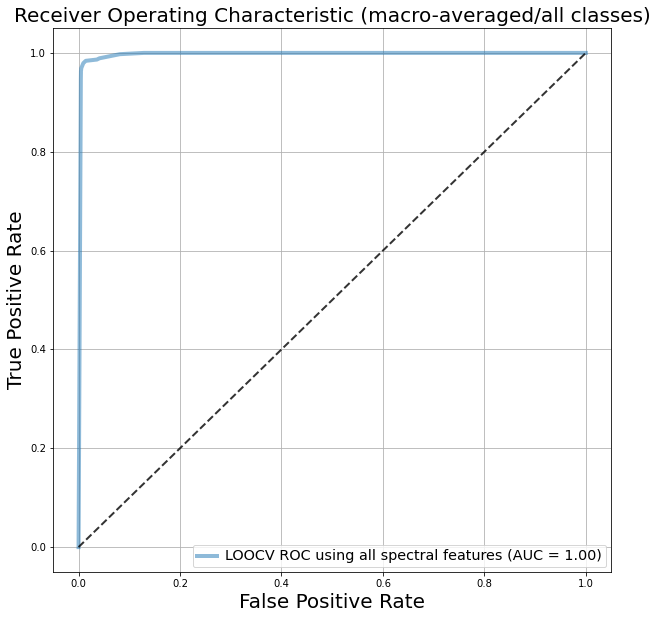

In [47]:
plt.figure(1, figsize=(10,10))
plt.plot(FPRs['macro'], TPRs['macro'], lw=4, alpha=0.5, label='LOOCV ROC using all spectral features (AUC = %0.2f)' % (AUCs['macro']))
# plt.plot(FPRs[7], TPRs[7], lw=4, alpha=0.5, label='LOOCV ROC using all spectral features (AUC = %0.2f)' % (AUCs[6]))
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='k', alpha=.8)


# Data_r3 = Data_r3.values
# all_y2 = []
# all_probs2=[]
# for train, test in kf.split(Data_r3, target):
#     all_y2.append(target[test])
#     all_probs2.append(model.fit(Data_r3[train], target[train]).predict_proba(Data_r3[test]))
# all_y2 = np.array(all_y2)
# all_probs2 = np.array(all_probs2)
# TPR2s = dict()
# FPR2s = dict()
# AUC2s = dict()
# for i in range(n_classes):
#     FPR2s[i], TPR2s[i], _ = roc_curve(all_y2,all_probs2[:,0,i],pos_label=performance['class'][i])

#     AUC2s[i] = auc(FPR2s[i], TPR2s[i])

# all_fpr2 = np.unique(np.concatenate([FPR2s[i] for i in range(n_classes)]))
# mean_tpr2 = np.zeros_like(all_fpr2)
# for i in range(n_classes):
#     mean_tpr2 += np.interp(all_fpr2, FPR2s[i], TPR2s[i])

# mean_tpr2 /= n_classes
# mean_tpr2[0] = 0.0
# FPR2s["macro"] = all_fpr2
# TPR2s["macro"] = mean_tpr2
# AUC2s["macro"] = auc(FPR2s["macro"], TPR2s["macro"])    

# plt.plot(FPR2s['macro'], TPR2s['macro'], lw=4, alpha=0.5, label='LOOCV ROC using selected spectral features (AUC = %0.2f)' % (AUC2s['macro']))

plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate',fontsize=20)
plt.ylabel('True Positive Rate',fontsize=20)
plt.title('Receiver Operating Characteristic (macro-averaged/all classes)',fontsize=20)
leg = plt.legend(loc="lower right")
leg_lines = leg.get_lines()
leg_texts = leg.get_texts()
plt.setp(leg_lines, linewidth=4)
plt.setp(leg_texts, fontsize='x-large')
plt.grid()
plt.show()

In [274]:
#load predicted labels from file

label = tmp_train['Label'].tolist()
# label
cv_results = pd.read_csv("NPL Cell probe Waters REIMS/LOOCV_results.csv")
# cv_results

In [347]:
# true labels for testing
test_label = tmp_test['Class'].tolist()
for i in range(len(test_label)):
    test_label[i] = test_label[i][4:]
# test_label

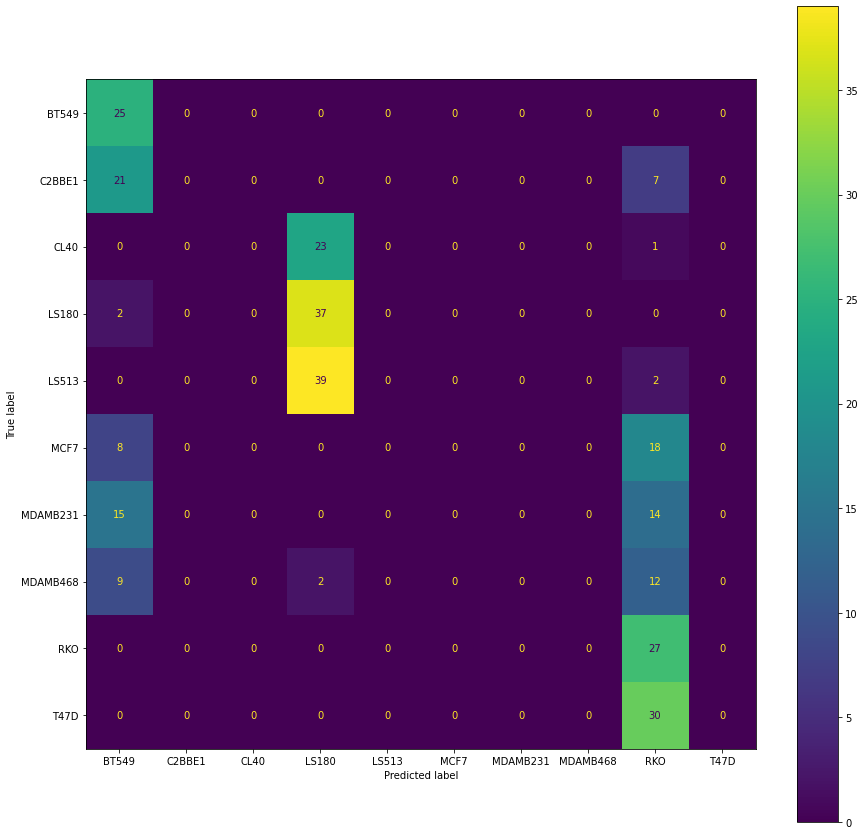

In [348]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
classes = label
classes = test_label
cm_label = np.unique(classes)

# CM = confusion_matrix(classes, cv_results)# cross-validation
CM = confusion_matrix(classes, test_results)# validation with test set
# CM
disp = ConfusionMatrixDisplay(confusion_matrix=CM, display_labels=cm_label)
disp.plot()
fig = plt.gcf()
fig.set_size_inches(15,15)

In [336]:
# function to calculate F1/pre/acc/sen/spe
def calculate_FPASS (cm,cm_label):
    dims = len(cm_label)
    results=pd.DataFrame(index=range(0,dims+1), columns=['class','accuracy','sensitivity','specificity','precision','F1'])
    results.iloc[:-1,0]=cm_label

    
    for i in range(dims):
        TP = cm[i][i]
        FP = np.sum(cm[i,:])-TP
        FN = np.sum(cm[:,i])-TP
        TN = np.sum(np.sum(cm))-TP-FP-FN
        results.iloc[i,2] = (TP)/(TP+FN)
        results.iloc[i,3] = (TN)/(TN+FP)
        results.iloc[i,4] = (TP)/(TP+FP)
        results.iloc[i,5] = 2*(TP)/(2*TP+FP+FN)
        results.iloc[i,1] = (results.iloc[i,2]+results.iloc[i,3])/2
    
    results.iloc[i+1,0]='Average'
    results.iloc[i+1,1] = np.mean(results.iloc[:,1])
    results.iloc[i+1,2] = np.mean(results.iloc[:,2])
    results.iloc[i+1,3] = np.mean(results.iloc[:,3])
    results.iloc[i+1,4] = np.mean(results.iloc[:,4])
    results.iloc[i+1,5] = np.mean(results.iloc[:,5])
    return results

In [349]:
performance = calculate_FPASS (CM,cm_label)
performance

D:\anaconda3\lib\site-packages\ipykernel_launcher.py:13: RuntimeWarning: invalid value encountered in longlong_scalars
  del sys.path[0]


,class,accuracy,sensitivity,specificity,precision,F1
0,BT549,0.65625,0.3125,1,1,0.47619
1,C2BBE1,NaN,NaN,0.90411,0,0
2,CL40,NaN,NaN,0.917808,0,0
3,LS180,0.677933,0.366337,0.989529,0.948718,0.528571
4,LS513,NaN,NaN,0.859589,0,0
5,MCF7,NaN,NaN,0.910959,0,0
6,MDAMB231,NaN,NaN,0.900685,0,0
7,MDAMB468,NaN,NaN,0.921233,0,0
8,RKO,0.621622,0.243243,1,1,0.391304
9,T47D,NaN,NaN,0.89726,0,0


In [350]:
# save results
performance.to_csv (r'results/test_results_cellprobe_waters.csv', index = False, header=True)
# cv_results.to_csv (r'ICL_NPL_COMBINED/LOOCV_results_cellprobe_waters_RFE.csv', index = False, header=True)

# Feature selection based on LR

In [165]:
start_time = time.time()

X = Data_log
y=tmp_train.iloc[:,1]
model=LogisticRegression(solver='liblinear', class_weight=weights)
yp=model.fit(X,y)

importance_LR=np.abs(yp.coef_)
size = (Data_log.shape)
importance_LR=np.reshape(importance_LR,(size[1], len(labelnames)))

idx_features = []
for i in range(0,len(labelnames)):
    idx_features.append(importance_LR[:,i].argsort()[:100])
    
idx_features = np.array(idx_features)
idx_features = np.unique(idx_features)
# idx_features.shape

features_LR = mz[idx_features]
features_LR=np.reshape(features_LR,(len(features_LR),1))

# features_LR
# np.savetxt('D:/BOX/Box Sync/RA/data/IMAGING/DESI/CRUK/project E/features_LR.txt',features_LR,delimiter=',')

elapsed_time = time.time() - start_time
print()
print('that took '+str(elapsed_time)+' seconds')


that took 0.39326906204223633 seconds


In [60]:
from sklearn.metrics import log_loss
from scipy.stats import chi2

def deviance(y, yp):
    return 2*log_loss(y, yp, normalize=False)

y=file.iloc[:,1]
model=LogisticRegression(solver='liblinear')
GOF=np.zeros((Data.shape[1],1))
for p in range(0,Data.shape[1]):
    print(p)
    X = Data_log.iloc[:,p].to_numpy()
    X=X.reshape(-1,1)
    yp=model.fit(X,y).predict_proba(X)
    yp_mean=np.zeros((len(Data),2))
    for i in range (0,len(Data)):
        yp_mean[i,0]=yp[:,0].mean()
        yp_mean[i,1]=yp[:,1].mean()
    res_deviance=deviance(y,yp)
    null_deviance=deviance(y,yp_mean)
    GOF[p]=null_deviance-res_deviance

chi2_pvals=np.zeros((Data.shape[1],1))
chi2_pvals=1-chi2.cdf(GOF , df=1)
plt.plot(mz,-np.log10(chi2_pvals))

idx_features2 = (-np.log10(chi2_pvals) > 1.5)
mz=mz.reshape(-1,1)
features_LR2=mz[idx_features2]
features_LR2.shape

## Trim data to only selected features & save

In [166]:
# Data_r=np.zeros((len(Data),len(features_ttest)))
Data_r=np.zeros((len(Data_log),len(features_LR)))
for n in range (0,len(features_LR)):
    index = np.argmin(abs(mz-features_LR[n]))
    Data_r[:,n]=Data_log.iloc[:,index]
# for n in range (0,len(features_ttest)):
#     Data_r[:,n]=file.iloc[:,(features_ttest[n])]
Data_r.shape

(233, 471)

In [167]:
output = pd.DataFrame(data=Data_r)
# output = output.T
output['Label'] = tmp_train['Class']
output['ID'] = tmp_train['Sample']
i = 0
for mz in features_LR:
#     print(mz)
    mz = float(mz)
    output = output.rename(columns={i: (mz)})
    i = i+1

# output.to_csv (r'feature selection/cell_probe_medimass_select_balanced.csv', index = False, header=True)
output

,107.0316,108.0056,115.0608,121.0162,128.0215,134.0336,135.0353,137.0137,139.0292,141.0061,...,1443.0673,1446.0752,1459.0984,1462.0719,1465.0513,1469.0795,1471.0828,1472.0984,Label,ID
0,7.686045,7.686045,7.686045,7.686045,9.079883,12.242560,9.580398,7.686045,7.686045,7.686045,...,8.476772,7.686045,7.686045,7.686045,7.686045,7.686045,7.686045,7.686045,ICL_BT549,ICL_BT549_TR1
1,7.923167,7.814756,8.211062,8.140354,7.802852,8.846392,8.021879,7.686045,7.686045,7.954617,...,7.686045,7.686045,7.686045,7.827606,7.686045,7.686045,7.686045,7.686045,ICL_BT549,ICL_BT549_TR2
2,7.686045,8.016028,8.195514,8.188749,8.043420,10.650947,8.736349,7.686045,7.686045,8.092943,...,7.970244,7.961568,7.907560,7.686045,7.686045,7.686045,7.855372,7.686045,ICL_BT549,ICL_BT549_TR3
3,7.967632,7.980334,8.096509,8.204418,7.933476,9.579347,8.508381,7.686045,7.848444,7.994753,...,7.686045,7.686045,7.686045,7.686045,7.819559,7.862868,7.686045,7.686045,ICL_BT549,ICL_BT549_TR4
4,7.931730,8.152454,8.205167,8.207364,7.973321,9.863793,8.338843,7.686045,7.686045,8.045805,...,7.686045,7.686045,7.686045,7.686045,7.815620,7.832259,7.686045,7.686045,ICL_BT549,ICL_BT549_TR5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
228,7.887516,8.019832,8.229260,8.054625,7.686045,7.686045,8.193344,8.021961,7.897011,7.991523,...,7.686045,7.769552,7.753444,7.686045,7.686045,7.686045,7.686045,7.686045,ICL_T47D,ICL_T47D_TR13
229,7.686045,8.100276,8.129624,8.270098,8.523129,10.053288,8.509471,8.205161,7.686045,7.686045,...,7.804385,7.803600,7.855435,7.795439,7.781632,7.686045,7.816115,7.686045,ICL_T47D,ICL_T47D_TR14
230,7.686045,7.868352,8.231521,8.156991,8.001494,9.284207,8.339096,8.119291,7.686045,7.898606,...,7.686045,7.686045,7.686045,7.686045,7.835390,7.686045,7.686045,7.686045,ICL_T47D,ICL_T47D_TR15
231,8.043463,8.038567,8.014022,8.036538,8.114013,9.210455,8.294768,8.236813,7.884675,8.022314,...,7.686045,7.686045,7.686045,7.686045,7.686045,7.686045,7.795579,7.686045,ICL_T47D,ICL_T47D_TR16


## RFE for further refinement of features

In [30]:
# RFE - use to select a fixed number of features
from sklearn.feature_selection import RFE

model = LogisticRegression(solver='liblinear')
RFE_features = []
start_time = time.time()
for i in range (0,1):
    print(i)
    label = file['Label'].tolist()
    selector = RFE(model, n_features_to_select=100, step=1)
    selector = selector.fit(Data_r, label)
    RFE_features.append(selector.support_)
elapsed_time = time.time() - start_time
print()
print('that took '+str(elapsed_time)+' seconds')

0

that took 31.388307571411133 seconds


In [168]:
# RFECV - use CV to determine & select best number of features
from sklearn.feature_selection import RFECV

model = LogisticRegression(solver='liblinear')
RFECV_features = []
start_time = time.time()
for i in range (0,1):
    print(i)
    label = tmp_train['Class'].tolist()
#     selector = RFECV(model, step=1)
    selector = RFECV(model, step=1, cv = 5, scoring = 'f1_weighted')
    selector = selector.fit(Data_r, label)
#     selector = selector.fit(Data_log, label)
    RFECV_features.append(selector.support_)
elapsed_time = time.time() - start_time
print()
print('that took '+str(elapsed_time)+' seconds')

0

that took 387.2653019428253 seconds


In [31]:
# Define new data matrix using only RFE features
for i, ite in enumerate(RFE_features):
    Data_r2 = Data_r
    Data_r2 = Data_r2.T
    mask = ite
    Data_r2 = Data_r2[mask]
    Data_r2 = Data_r2.T
Data_r2.shape

(138, 100)

In [175]:
for i, ite in enumerate(RFECV_features):
    Data_r3 = Data_r
    Data_r3 = Data_r3.T
    mask = ite
    Data_r3 = Data_r3[mask]
    Data_r3 = Data_r3.T
Data_r3.shape

(233, 121)

In [81]:
# mz_trimmed = output.columns.values[:-2]
# mz_trimmed
# mz_RFE = mz_trimmed[mask]
# mz_RFE

In [176]:
mz_trimmed = output.columns.values[:-2]
# mz_trimmed = Data.columns.values[:]
mz_RFE = mz_trimmed[mask]
output = pd.DataFrame(data=Data_r3)
output['Label'] = tmp_train['Class']
output['ID'] = tmp_train['Sample']
i = 0
for mz in mz_RFE:
#     print(mz)
    mz = float(mz)
    output = output.rename(columns={i: (mz)})
    i = i+1

output.to_csv (r'feature selection/bipolar_medimass_combined_RFE_balanced.csv', index = False, header=True)
output

,107.0316,115.0608,134.0336,137.0137,170.8248,199.0626,213.1785,214.0668,219.17,229.0494,...,862.658,863.5756,864.6706,865.7011,894.7405,895.7471,896.5981,921.7618,Label,ID
0,7.686045,7.686045,12.242560,7.686045,7.686045,8.589793,7.686045,9.603860,10.937835,7.686045,...,7.686045,7.686045,7.686045,8.133342,7.686045,7.686045,7.686045,7.686045,ICL_BT549,ICL_BT549_TR1
1,7.923167,8.211062,8.846392,7.686045,7.686045,7.802420,8.010551,7.932047,10.964431,7.686045,...,7.686045,7.686045,7.686045,7.741282,7.686045,7.686045,7.686045,7.686045,ICL_BT549,ICL_BT549_TR2
2,7.686045,8.195514,10.650947,7.686045,7.686045,7.974683,8.029785,8.529378,10.882104,7.686045,...,7.686045,7.686045,7.686045,7.686045,7.890556,7.896542,7.686045,7.844067,ICL_BT549,ICL_BT549_TR3
3,7.967632,8.096509,9.579347,7.686045,7.686045,8.035720,7.974288,8.123062,10.764346,7.686045,...,7.686045,7.686045,7.686045,7.686045,7.835785,7.686045,7.686045,7.819771,ICL_BT549,ICL_BT549_TR4
4,7.931730,8.205167,9.863793,7.686045,7.686045,7.912180,7.939240,8.094086,10.923941,7.686045,...,7.686045,7.686045,7.686045,7.686045,7.818380,7.838513,7.686045,7.686045,ICL_BT549,ICL_BT549_TR5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
228,7.887516,8.229260,7.686045,8.021961,7.686045,7.686045,7.995401,8.087341,10.968753,7.686045,...,8.117140,7.686045,7.959350,7.859552,7.686045,7.686045,7.842547,7.686045,ICL_T47D,ICL_T47D_TR13
229,7.686045,8.129624,10.053288,8.205161,7.913637,7.686045,8.022109,8.373967,10.978775,7.686045,...,8.131971,7.686045,7.974702,7.856419,7.761398,7.686045,7.838790,7.686045,ICL_T47D,ICL_T47D_TR14
230,7.686045,8.231521,9.284207,8.119291,7.686045,7.686045,8.033509,8.245859,10.879875,7.686045,...,7.971183,7.686045,7.815133,7.870843,7.773394,7.801674,7.686045,7.686045,ICL_T47D,ICL_T47D_TR15
231,8.043463,8.014022,9.210455,8.236813,7.686045,7.686045,8.088658,8.116556,10.875692,7.686045,...,7.869350,7.686045,7.806249,7.686045,7.754200,7.750126,7.686045,7.686045,ICL_T47D,ICL_T47D_TR16


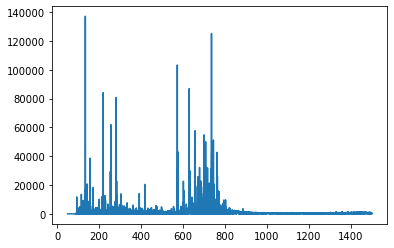

In [51]:
mean_spec = np.mean(Data.values,axis = 0)
# mz_ind= np.argmin(abs(mz-mz_selected[80]))
plt.plot(mz_trans,mean_spec)

In [52]:
np.savetxt('Bipolar forceps_Medimass_REIMS_07072020/spec_ref.txt', mean_spec,delimiter=',')

## Data binning for Thermo data (high res)

In [56]:
thermo_features = []
for i in range(0,len(mz_RFE)): thermo_features.append(float(mz_RFE[i]))
# thermo_features

In [84]:
features_av = []
Data_bin = []

i_start = 0
for i in range(0,len(thermo_features)):
    if i < len(thermo_features)-1:
        if abs((thermo_features[i+1])-(thermo_features[i])) < 0.01:
             continue
        else:
            if i != i_start:
                features_av.append(np.mean(thermo_features[i_start:i]))
                Data_bin.append(np.sum(Data_r3.values[:,i_start:i], axis=1))
            else:
                features_av.append(thermo_features[i])
                Data_bin.append(Data_r3.values[:,i])
            i_start = i+1
#             print(i_start)
    else:
        features_av.append(np.mean(thermo_features[i:]))
        Data_bin.append(np.sum(Data_r3.values[:,i:], axis=1))

In [85]:
output = pd.DataFrame(data=Data_bin)
output = output.T
output['Label'] = file['Label']
output['ID'] = file['ID']
i = 0
for mz in thermo_features:
#     print(mz)
    mz = float(mz)
    output = output.rename(columns={i: (mz)})
    i = i+1

output.to_csv (r'feature selection/bipolar_forceps_thermo_binned.csv', index = False, header=True)

Data_bin = output.iloc[:,:-2]
output


,281.248443603516,281.249237060547,283.263977050781,311.166442871094,311.167358398438,311.168304443359,311.169219970703,325.182586669922,325.18359375,325.1845703125,...,702.541015625,702.544128417969,702.547241210938,704.559143066406,705.485046386719,709.438232421875,709.457275390625,709.517456054688,Label,ID
0,9.121548,6.720767,20.712618,13.779498,13.548016,19.691301,21.392490,6.744130,17.772228,28.677857,...,26.047978,7.390243,25.254252,5.712675,5.771622,6.326280,6.236727,6.280255,BT549,BT549_TR172
1,6.131245,4.276536,13.462492,8.862189,8.801343,12.704999,13.312565,4.542596,11.428903,18.964007,...,17.418138,4.876532,16.782637,4.228957,3.809634,4.259911,4.434297,4.603186,BT549,BT549_TR173
2,6.884089,5.123451,14.177197,9.385705,9.270101,13.793529,15.709073,4.699555,11.428903,19.436304,...,18.019312,5.039565,17.995782,3.809634,4.380404,4.567876,4.531449,4.739673,BT549,BT549_TR174
3,7.816637,5.550792,16.612881,11.310048,10.922848,16.684547,18.024732,5.661869,14.700756,24.128113,...,21.865954,6.480951,20.751876,5.021837,5.132844,5.524103,5.388974,5.593947,BT549,BT549_TR24
4,5.687594,4.088319,12.450830,7.619269,7.619269,11.428903,13.326735,3.809634,11.428903,16.583674,...,15.238538,4.404979,16.725203,3.809634,3.809634,3.809634,4.257068,4.338069,BT549,BT549_TR25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133,8.686530,6.150352,15.330281,10.750113,10.368108,18.799513,19.091651,5.758677,17.666722,26.948251,...,22.461167,6.717325,22.130932,5.058768,5.943841,5.607544,5.817490,6.032995,T47D,T47D_TR33
134,5.682419,4.144822,11.428903,7.619269,7.619269,12.167899,13.031349,4.108476,11.428903,16.858941,...,15.238538,4.419136,15.238538,3.809634,3.809634,3.809634,3.809634,3.809634,T47D,T47D_TR34
135,6.331667,4.447228,11.428903,7.619269,8.052520,13.294821,13.527973,4.364780,12.533558,19.518030,...,15.238538,4.693433,17.210602,3.809634,3.809634,3.809634,4.416882,4.262125,T47D,T47D_TR44
136,5.354955,3.809634,11.428903,7.619269,7.619269,11.428903,12.502883,3.809634,11.428903,16.643891,...,15.238538,3.809634,15.238538,3.809634,3.809634,3.809634,3.809634,3.809634,T47D,T47D_TR45


## Feature selection with LASSO

In [92]:
from sklearn.preprocessing import label_binarize
from sklearn.linear_model import Lasso
from sklearn.linear_model import LassoCV

target = file['Label']
target = label_binarize(target,classes=["APC_control", "APC_KRAS_control"])

lasso=LassoCV(max_iter=10000,tol=1e-3,n_alphas=1000,cv=10)
# lasso = Lasso(max_iter=2000,tol=1e-3,)

clf2=lasso.fit(Data_log,target)
clf2.score(Data_log,target)

0.8944292544064886

In [81]:
# from sklearn.model_selection import KFold
# from sklearn.model_selection import GridSearchCV

# lasso = Lasso(tol=1e-3, max_iter=10000)
# alphas = np.logspace(-4, -0.5, 30)
# tuned_parameters = [{'alpha': alphas}]

# clf = GridSearchCV(lasso, tuned_parameters, cv=5, refit=False)
# clf.fit(Data, target)
# scores = clf.cv_results_['mean_test_score']
# scores_std = clf.cv_results_['std_test_score']
# # cvFold_lasso = logo.split(Data,target,groups=tmp1['ID'])
# cv_results_LASSO = cross_val_score(lasso, Data, target, cv=5,scoring='accuracy')
# cv_results_LASSO.mean()

[111.94749295 124.00765482 146.04623491 152.00265354 175.0250572
 187.09790481 255.23304529 256.23655789 271.00414311 279.23310099
 281.24842896 282.25207944 283.2640927  286.97788247 295.22777379
 303.23299905 304.23642666 331.26371909 337.19138222 346.05547046
 433.33126956 512.26836482 552.29500444 599.32681026 664.41789029
 699.497444   744.55165229 766.53886649 768.54405694 769.55353343
 790.5376856  865.50331648 886.55311453 887.559667  ]


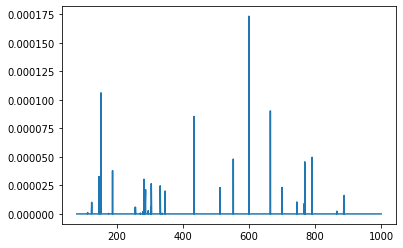

In [93]:
importance = np.abs(clf2.coef_)
selection=(importance != 0)
features_lasso=mz[selection]
# selection=importance[selection]
# idx_features2 = (-selection).argsort()
# importance[idx_features2]

print(features_lasso)
plt.plot(mz,importance)
np.savetxt('D:/BOX/Box Sync/RA/data/IMAGING/DESI/CRUK/project E/features_lasso.txt',features_lasso,delimiter=',')

# Feature selection with univariate analysis

In [6]:
from bioinfokit import analys, visuz
from scipy import stats

# control=file['Label']!= "APC_sim"
class1=file['Label']== "Positive"
class2=file['Label']== "Negative"
# control=tmp1[class1]
green_data=Data[class1]
# APC=tmp1[class2]
red_data=Data[class2]
# APC_data

#Kruskal-Wallis test (non-parametric for multiple groups)

p_vals_KW=np.zeros(len(mz))
for i in range(len(mz)):
#     print(i)
    if (np.round(np.mean(green_data.iloc[:,i]),4))== (np.round(np.mean(red_data.iloc[:,i]),4)):
        p_vals_KW[i]=1
    else:
        dum1=stats.kruskal(green_data.iloc[:,i],red_data.iloc[:,i])
        dum2=dum1.pvalue
        p_vals_KW[i]=(dum2)        

In [17]:
#Mann-Whitney test (non-parametric binary problem)

p_vals_MW=np.zeros(len(mz))
for i in range(len(mz)):
#     print(i)
    if (np.round(np.mean(green_data.iloc[:,i]),4))== (np.round(np.mean(red_data.iloc[:,i]),4)):
        p_vals_MW[i]=1
    else:
        dum1=stats.mannwhitneyu(green_data.iloc[:,i],red_data.iloc[:,i])
        dum2=dum1.pvalue
        p_vals_MW[i]=(dum2)

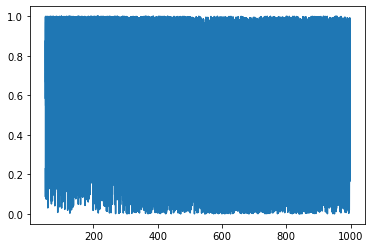

In [7]:
plt.plot(mz,p_vals_KW)

# KW test = MW test for a two-way comparison~

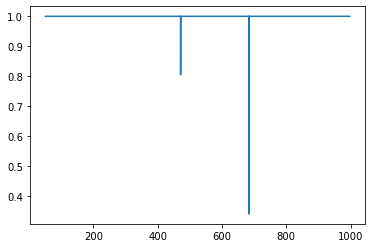

In [18]:
#FDR correction

[rejected,correct_p]=statsmodels.stats.multitest.fdrcorrection(p_vals_KW, alpha=0.05, method='indep', is_sorted=False)

plt.plot(mz,correct_p)
# p_vals.shape

In [19]:
features = [correct_p <= 0.99]
features_KW = mz[features]
features_KW
# np.mean(correct_p)

D:\anaconda3\lib\site-packages\ipykernel_launcher.py:2: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  


array([471.37023926, 471.38635254, 683.79107666])

In [9]:
#fold changes calculation

green_mean=np.mean(green_data.iloc[:,:])
green_mean=np.where(green_mean==0, 1, green_mean) 
red_mean=np.mean(red_data.iloc[:,:])
red_mean=np.where(red_mean==0, 1, red_mean) 

fc=green_mean/red_mean
log2fc=np.log2(fc)
# plt.plot(mz,fc)
# plt.plot(mz,control_mean)
# plt.plot(mz,APC_mean)

## Volcano plot

In [10]:
# plot and save volcano plot
# mzlabel=np.zeros(len(mz))
mzlabel=[''] * len(mz)
for i in range(len(mz)):
    mzlabel[i]=str(mz[i])
# dum=np.vstack((correct_p,log2fc,mzlabel))
# dum=dum.transpose()

volcano_data=pd.DataFrame(index=range(0,len(mz)),columns=['pvals','fc','mz'])
volcano_data.iloc[:,0]=correct_p
volcano_data.iloc[:,1]=log2fc
volcano_data.iloc[:,2]=mzlabel
top30=volcano_data['pvals'].sort_values(ascending=True)
top30 = top30[0:30].index
# labels=mz[top30]
labels=np.array2string(mz[top30],separator=',',precision=12)
# print(labels)


# mz_label
# visuz.gene_exp.volcano(df=volcano_data, lfc='fc', pv='pvals')

visuz.gene_exp.volcano(df=volcano_data, lfc='fc', pv='pvals',geneid="mz",genenames=labels,
                       lfc_thr=1,pv_thr=0.05,sign_line=True)
# check=volcano_data['mz']=='168.8583166826'
# mz[check]

AssertionError: either significant up or down genes are missing; try to lower lfc_thr or increase pv_thr

In [16]:
# select and save spectral features according volcano plot thresholds
condition=(volcano_data['pvals'] <= 1e-200) & (abs(volcano_data['fc']) >= 2.5)
features=mz[condition]
# print(volcano_data[check])
print(features.shape)
# np.savetxt('D:/BOX/Box Sync/RA/data/IMAGING/DESI/CRUK/project B/features_volcano_low_thresh.txt',features,delimiter=',')
# # print(condition)
# features


(847,)


# Box plotting

In [351]:
# function to box plot
def box_plot (features,mz,box_data, save = False, savepath = None):
    group_label = list(box_data.columns)
#     for i in range(group_label):
    #         colors = {"APC_control": "g", "APC_sim": "g","APC_KRAS_control": "r", "APC_KRAS_sim": "r",
#                  "APC_P53_control": "y", "APC_P53_sim": "y","APC_KRAS_P53_control": "b", "APC_KRAS_P53_sim": "b"}
    for feature in features:
        index= np.argmin(abs(mz-float(feature)))
        fig = plt.figure(figsize=(15,8))
        sns.boxplot(x="Label", y=box_data.columns[index+2], data=box_data, whis=5, palette = 'Set1')
        if save == True:
            filename = 'BP_'+box_data.columns[index+2]
            path = os.path.join(savepath, 'box_plots')
            if not os.path.exists(path):
                os.mkdir(path)
            os.chdir(path)
            fig.savefig(filename+'.png')
            plt.close()
            print('plot for '+str(feature)+' saved.')
    os.chdir('..')

(0.0, 4.0)

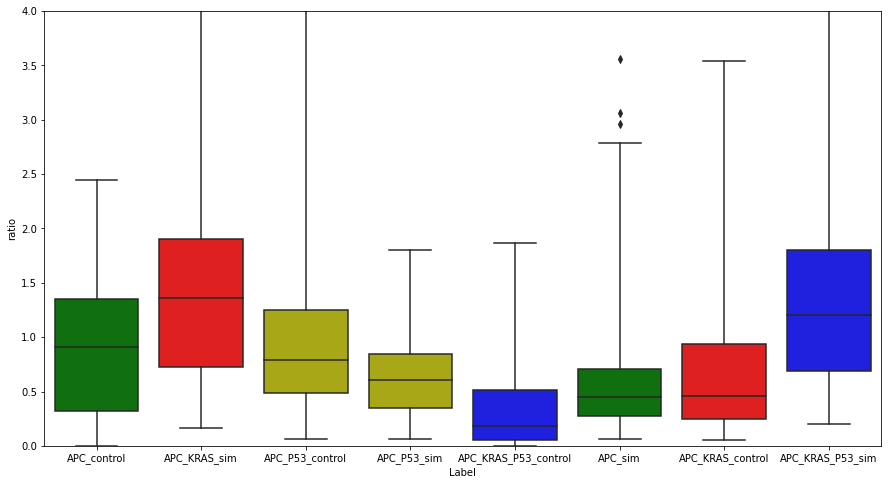

In [28]:
box_plot(np.array(Data_r3.columns.values),mz,file, save=True, savepath = "D:/BOX/Box Sync/RA/data/IMAGING/LD_REIMS/from Vince/cambridge multiple sclerosis/")